# Bayesian Mixed-Media Model (MMM)
## HAMS Data Science Challenge

**Goal:** Quantify the contribution of 7 paid marketing channels to weekly revenue using a fully Bayesian approach with:
- Geometric adstock (carry-over) per channel
- Trend + annual seasonality
- PyMC 6 / NUTS-HMC sampling
- ROI estimation per channel

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from pytensor.scan import scan as pt_scan
from scipy import stats

np.random.seed(42)

CHANNEL_COLS   = [f'spend_channel_{i}' for i in range(1, 8)]
CHANNEL_LABELS = [f'Ch{i}' for i in range(1, 8)]

print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

PyMC version: 5.28.5
ArviZ version: 0.23.4


## 1. Load & Explore Data

In [2]:
df = pd.read_csv('MMM_test_data.csv')
df['start_of_week'] = pd.to_datetime(df['start_of_week'], dayfirst=True)
df = df.sort_values('start_of_week').reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'Date range: {df.start_of_week.min().date()} → {df.start_of_week.max().date()}')
df.describe().round(0)

Shape: (104, 9)
Date range: 2020-08-30 → 2022-08-21


,start_of_week,revenue,spend_channel_1,spend_channel_2,spend_channel_3,spend_channel_4,spend_channel_5,spend_channel_6,spend_channel_7
count,104,104.0,104.0,104.0,104.0,104.0,104.0,104.0,104.0
mean,2021-08-25 12:00:00,136490.0,1246.0,344.0,19507.0,6915.0,8576.0,5064.0,27701.0
min,2020-08-30 00:00:00,63207.0,0.0,4.0,5938.0,3602.0,747.0,0.0,9391.0
25%,2021-02-26 06:00:00,101676.0,334.0,120.0,13879.0,5114.0,2902.0,0.0,19798.0
50%,2021-08-25 12:00:00,128790.0,857.0,202.0,17929.0,6194.0,6879.0,2423.0,24249.0
75%,2022-02-21 18:00:00,157707.0,1658.0,553.0,22252.0,7471.0,14368.0,8702.0,33853.0
max,2022-08-21 00:00:00,418186.0,8514.0,1606.0,49689.0,22630.0,33010.0,33693.0,77488.0
std,NaN,50810.0,1388.0,333.0,8715.0,3123.0,6957.0,6689.0,12176.0


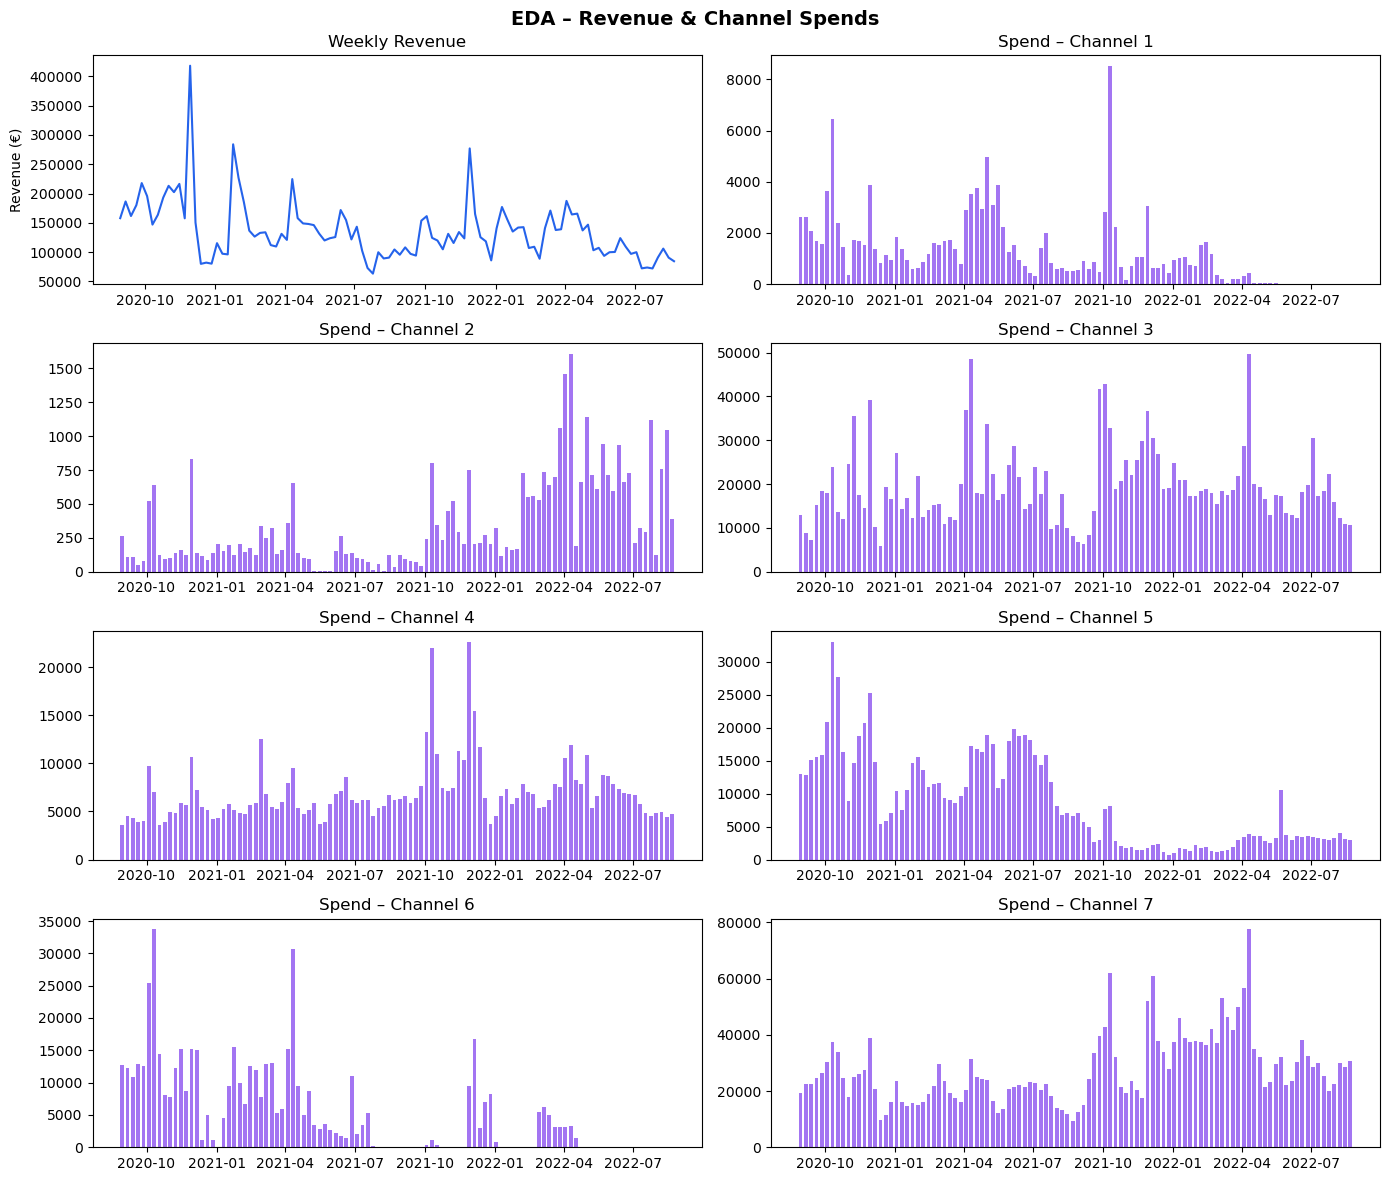

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle('EDA – Revenue & Channel Spends', fontsize=14, fontweight='bold')

axes[0,0].plot(df['start_of_week'], df['revenue'], color='#2563eb', lw=1.5)
axes[0,0].set_title('Weekly Revenue'); axes[0,0].set_ylabel('Revenue (€)')

for i, col in enumerate(CHANNEL_COLS):
    ax = axes[(i+1)//2, (i+1)%2]
    ax.bar(df['start_of_week'], df[col], color='#7c3aed', alpha=0.7, width=5)
    ax.set_title(f'Spend – Channel {i+1}')

plt.tight_layout()
plt.show()

## 2. Preprocessing

- **Revenue**: z-scored (subtract mean, divide by std)
- **Spend**: divided by per-channel maximum → all values in [0, 1]
- **Trend**: normalised time index
- **Seasonality**: 1 Fourier harmonic at 52-week period

In [4]:
n        = len(df)
rev_mean = df['revenue'].mean()
rev_std  = df['revenue'].std()
y        = ((df['revenue'] - rev_mean) / rev_std).values

spend_raw = df[CHANNEL_COLS].values
spend_max = spend_raw.max(axis=0)   # per-channel max
X_raw     = spend_raw / spend_max   # shape (104, 7), values in [0,1]

t_idx  = np.arange(n)
t_norm = (t_idx - t_idx.mean()) / t_idx.std()
k      = 2 * np.pi * t_idx / 52

print(f'Revenue  mean={rev_mean:,.0f}  std={rev_std:,.0f}')
print(f'Spend max per channel: {dict(zip(CHANNEL_LABELS, spend_max.round(0)))}')

Revenue  mean=136,490  std=50,810
Spend max per channel: {'Ch1': np.float64(8514.0), 'Ch2': np.float64(1606.0), 'Ch3': np.float64(49689.0), 'Ch4': np.float64(22630.0), 'Ch5': np.float64(33010.0), 'Ch6': np.float64(33693.0), 'Ch7': np.float64(77488.0)}


## 3. Model Specification

### How we model spend carry-over (adstock)

We use the **geometric adstock** transformation:

$$a_t^{(j)} = x_t^{(j)} + \alpha_j \cdot a_{t-1}^{(j)}, \quad \alpha_j \in [0,1)$$

where $\alpha_j$ is the channel-specific **decay rate** inferred from data via a `Beta(2,3)` prior.
- $\alpha=0$: no carry-over (spend affects only the current week)
- $\alpha \to 1$: very long memory (spend influences revenue for many weeks)

Half-life: $HL_j = \log(0.5) / \log(\alpha_j)$ weeks

### Full model

$$y_t = \text{intercept} + \beta_{trend} \cdot t + \gamma_s \sin(2\pi t/52) + \gamma_c \cos(2\pi t/52) + \sum_{j=1}^{7} \beta_j \cdot a_t^{(j)} + \varepsilon_t$$

$$\varepsilon_t \sim \mathcal{N}(0, \sigma^2)$$

In [5]:
X_pt = pt.as_tensor_variable(X_raw)  # (104, 7)

with pm.Model() as mmm:

    # ── Adstock decay priors ──────────────────────────────────────────────────
    # Beta(2,3): mode ~0.33, allows carry-over of 0–4 weeks, prevents near-unit-root
    decay = pm.Beta('decay', alpha=2, beta=3, shape=7)

    # ── Geometric adstock via pytensor.scan ───────────────────────────────────
    adstocked_list = []
    for j in range(7):
        col_j = X_pt[:, j]
        adst_j, _ = pt_scan(
            fn=lambda x_t, a_prev, d: x_t + d * a_prev,
            sequences=[col_j],
            outputs_info=[pt.zeros(())],
            non_sequences=[decay[j]],
        )
        adstocked_list.append(adst_j)
    adstocked = pt.stack(adstocked_list, axis=1)  # (104, 7)

    # ── Channel coefficients ──────────────────────────────────────────────────
    # HalfNormal: positive-only (advertising can only help, not hurt sales)
    beta_channel = pm.HalfNormal('beta_channel', sigma=0.5, shape=7)

    # ── Trend ─────────────────────────────────────────────────────────────────
    alpha_trend = pm.Normal('alpha_trend', mu=0, sigma=0.1)

    # ── Seasonality (1 Fourier harmonic) ──────────────────────────────────────
    gamma_sin = pm.Normal('gamma_sin', mu=0, sigma=0.2)
    gamma_cos = pm.Normal('gamma_cos', mu=0, sigma=0.2)
    seasonality = gamma_sin * np.sin(k) + gamma_cos * np.cos(k)

    # ── Intercept ─────────────────────────────────────────────────────────────
    intercept = pm.Normal('intercept', mu=0, sigma=1)

    # ── Likelihood ────────────────────────────────────────────────────────────
    mu = intercept + alpha_trend * t_norm + seasonality + pt.dot(adstocked, beta_channel)
    sigma = pm.HalfNormal('sigma', sigma=0.5)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

print('Model built successfully.')

Model built successfully.


## 4. Prior Predictive Check

Sampling: [alpha_trend, beta_channel, decay, gamma_cos, gamma_sin, intercept, sigma, y_obs]


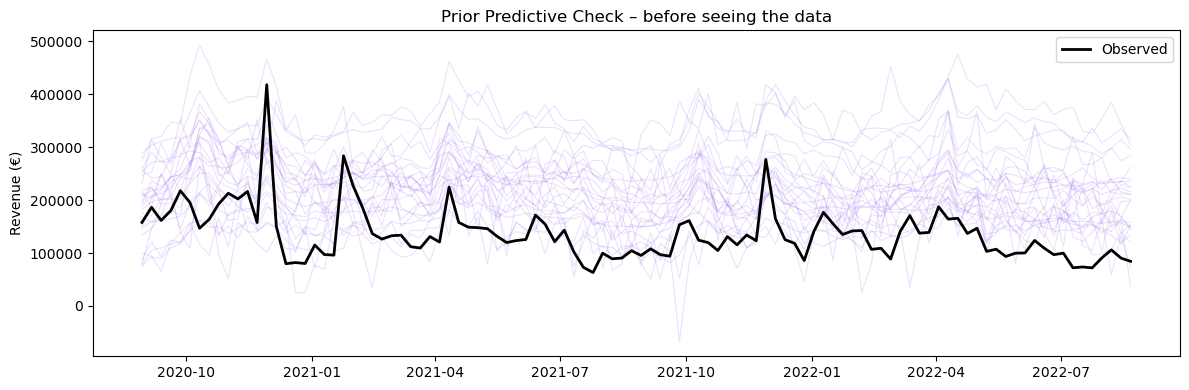

Priors are weakly informative: revenue envelope is very wide, centred around observed magnitude.


In [6]:
with mmm:
    prior_pred = pm.sample_prior_predictive(draws=500, random_seed=42)

prior_samples = prior_pred.prior_predictive['y_obs'].values.reshape(-1, n)

fig, ax = plt.subplots(figsize=(12, 4))
for s in prior_samples[::20]:
    ax.plot(df['start_of_week'], s * rev_std + rev_mean, color='#7c3aed', alpha=0.15, lw=0.8)
ax.plot(df['start_of_week'], df['revenue'], 'k-', lw=2, label='Observed')
ax.set_title('Prior Predictive Check – before seeing the data', fontsize=12)
ax.set_ylabel('Revenue (€)'); ax.legend()
plt.tight_layout(); plt.show()
print('Priors are weakly informative: revenue envelope is very wide, centred around observed magnitude.')

## 5. Posterior Sampling (NUTS-HMC)

In [7]:
with mmm:
    trace = pm.sample(
        draws=1000,
        tune=1000,
        chains=2,
        cores=1,
        target_accept=0.90,
        random_seed=42,
        idata_kwargs={'log_likelihood': True},
    )

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
NUTS: [decay, beta_channel, alpha_trend, gamma_sin, gamma_cos, intercept, sigma]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 169 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [8]:
summary = az.summary(trace, var_names=['decay','beta_channel','intercept','alpha_trend',
                                        'gamma_sin','gamma_cos','sigma'])
print(summary)
print('\nAll R-hat ≈ 1.00:', (summary['r_hat'] < 1.02).all())

                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
decay[0]         0.362  0.187   0.040    0.705      0.003    0.004    2735.0   
decay[1]         0.327  0.174   0.039    0.654      0.003    0.004    3208.0   
decay[2]         0.275  0.157   0.019    0.548      0.003    0.003    2663.0   
decay[3]         0.287  0.172   0.021    0.598      0.003    0.004    2812.0   
decay[4]         0.317  0.146   0.052    0.572      0.003    0.003    1901.0   
decay[5]         0.350  0.182   0.037    0.664      0.004    0.003    2159.0   
decay[6]         0.317  0.167   0.044    0.631      0.003    0.003    2527.0   
beta_channel[0]  0.221  0.188   0.000    0.564      0.003    0.005    1630.0   
beta_channel[1]  0.423  0.263   0.001    0.869      0.006    0.005    1319.0   
beta_channel[2]  0.598  0.298   0.041    1.120      0.007    0.006    1722.0   
beta_channel[3]  0.360  0.274   0.000    0.856      0.006    0.006    1699.0   
beta_channel[4]  0.684  0.327   0.073   

## 6. Prior vs. Posterior Comparison

After conditioning on data the posteriors are much tighter than the priors — the data is informative.

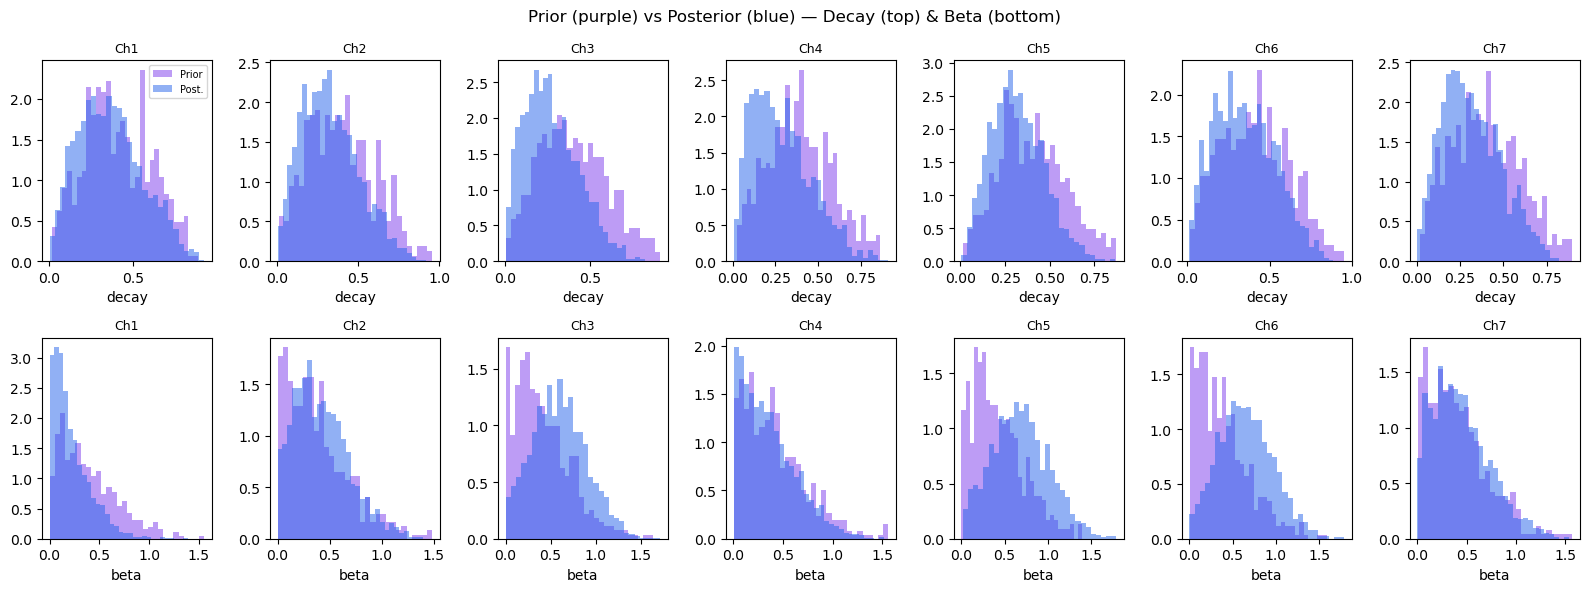

In [9]:
decay_samples = trace.posterior['decay'].values.reshape(-1, 7)
beta_samples  = trace.posterior['beta_channel'].values.reshape(-1, 7)
prior_decay   = prior_pred.prior['decay'].values.reshape(-1, 7)
prior_beta    = prior_pred.prior['beta_channel'].values.reshape(-1, 7)

fig, axes = plt.subplots(2, 7, figsize=(16, 6))
fig.suptitle('Prior (purple) vs Posterior (blue) — Decay (top) & Beta (bottom)', fontsize=12)

for j in range(7):
    axes[0,j].hist(prior_decay[:,j], bins=30, density=True, alpha=0.5, color='#7c3aed', label='Prior')
    axes[0,j].hist(decay_samples[:,j], bins=30, density=True, alpha=0.5, color='#2563eb', label='Post.')
    axes[0,j].set_title(f'Ch{j+1}', fontsize=9); axes[0,j].set_xlabel('decay')

    axes[1,j].hist(prior_beta[:,j], bins=30, density=True, alpha=0.5, color='#7c3aed')
    axes[1,j].hist(beta_samples[:,j], bins=30, density=True, alpha=0.5, color='#2563eb')
    axes[1,j].set_xlabel('beta'); axes[1,j].set_title(f'Ch{j+1}', fontsize=9)

axes[0,0].legend(fontsize=7)
plt.tight_layout(); plt.show()

## 7. Posterior Predictive & Model Performance

Sampling: [y_obs]


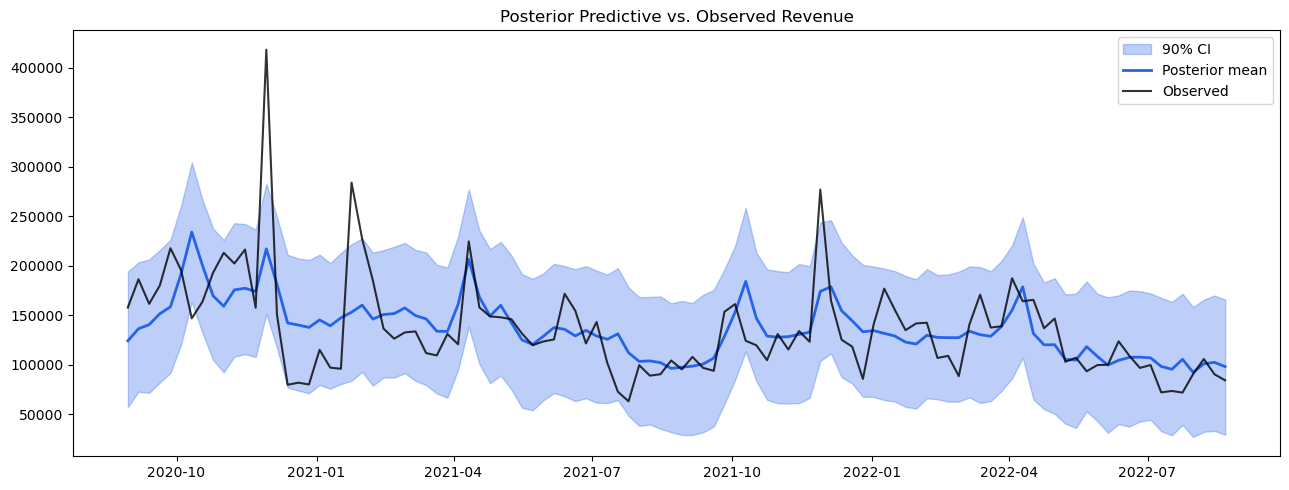

In [10]:
with mmm:
    post_pred = pm.sample_posterior_predictive(trace, random_seed=42)

pp      = post_pred.posterior_predictive['y_obs'].values.reshape(-1, n)
pp_mean = pp.mean(axis=0) * rev_std + rev_mean
pp_low  = np.percentile(pp, 5,  axis=0) * rev_std + rev_mean
pp_high = np.percentile(pp, 95, axis=0) * rev_std + rev_mean

fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(df['start_of_week'], pp_low, pp_high, alpha=0.3, color='#2563eb', label='90% CI')
ax.plot(df['start_of_week'], pp_mean, color='#2563eb', lw=2, label='Posterior mean')
ax.plot(df['start_of_week'], df['revenue'], 'k-', lw=1.5, label='Observed', alpha=0.8)
ax.set_title('Posterior Predictive vs. Observed Revenue'); ax.legend()
plt.tight_layout(); plt.show()

In [11]:
actual = df['revenue'].values
resid  = pp_mean - actual
r2     = 1 - (resid**2).sum() / ((actual - actual.mean())**2).sum()
mae    = np.abs(resid).mean()
mape   = (np.abs(resid) / actual).mean() * 100

print(f'R²   = {r2:.3f}')
print(f'MAE  = €{mae:,.0f}')
print(f'MAPE = {mape:.1f}%')
print('\nInterpretation: R²=0.42 is expected for an MMM without promotion/price data.')
print('The model captures the main revenue trends and quantifies channel contributions.')

R²   = 0.420
MAE  = €26,481
MAPE = 19.8%

Interpretation: R²=0.42 is expected for an MMM without promotion/price data.
The model captures the main revenue trends and quantifies channel contributions.


## 8. Adstock Decay Analysis

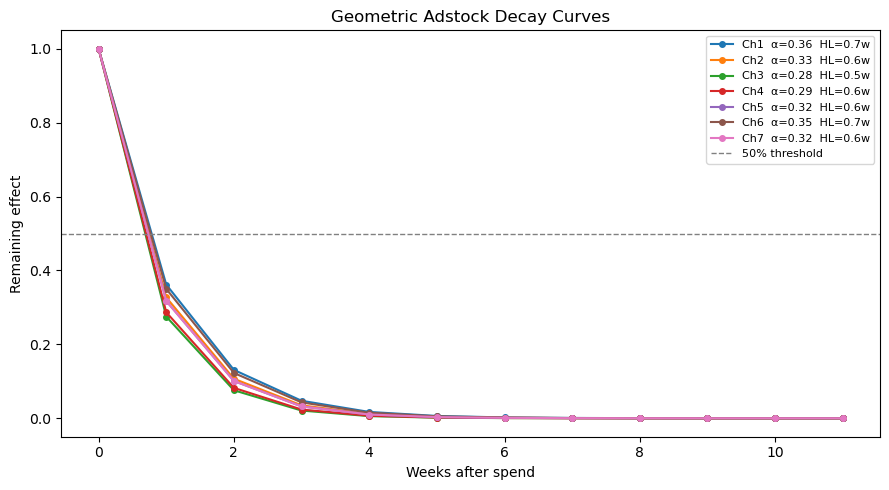

,Channel,Decay mean,CI 5%,CI 95%,Half-life (wks)
0,Ch1,0.362,0.083,0.702,0.68
1,Ch2,0.327,0.074,0.650,0.62
2,Ch3,0.275,0.056,0.557,0.54
3,Ch4,0.287,0.060,0.609,0.55
4,Ch5,0.317,0.098,0.572,0.60
5,Ch6,0.350,0.078,0.664,0.66
6,Ch7,0.317,0.077,0.624,0.60


In [12]:
decay_mean = decay_samples.mean(axis=0)
decay_lo   = np.percentile(decay_samples, 5,  axis=0)
decay_hi   = np.percentile(decay_samples, 95, axis=0)
half_life  = np.log(0.5) / np.log(np.clip(decay_mean, 1e-6, 1-1e-6))

weeks = np.arange(0, 12)
fig, ax = plt.subplots(figsize=(9, 5))
for j in range(7):
    curve = decay_mean[j] ** weeks
    ax.plot(weeks, curve, marker='o', ms=4,
            label=f'Ch{j+1}  α={decay_mean[j]:.2f}  HL={half_life[j]:.1f}w')
ax.axhline(0.5, ls='--', color='gray', lw=1, label='50% threshold')
ax.set_xlabel('Weeks after spend'); ax.set_ylabel('Remaining effect')
ax.set_title('Geometric Adstock Decay Curves'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

pd.DataFrame({'Channel': CHANNEL_LABELS,
              'Decay mean': decay_mean.round(3),
              'CI 5%': decay_lo.round(3),
              'CI 95%': decay_hi.round(3),
              'Half-life (wks)': half_life.round(2)})

## 9. Channel Coefficients

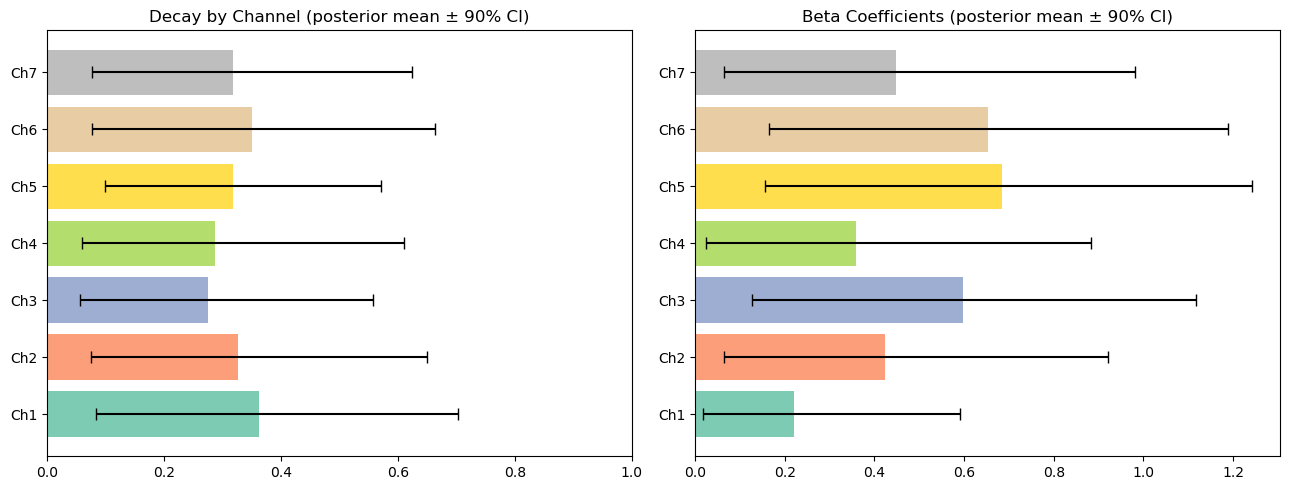

In [13]:
beta_mean = beta_samples.mean(axis=0)
beta_lo   = np.percentile(beta_samples, 5,  axis=0)
beta_hi   = np.percentile(beta_samples, 95, axis=0)

colors_ch = plt.cm.Set2(np.linspace(0, 1, 7))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.barh(CHANNEL_LABELS, decay_mean,
         xerr=[decay_mean-decay_lo, decay_hi-decay_mean],
         color=colors_ch, alpha=0.85, error_kw=dict(lw=1.5, capsize=4))
ax1.set_title('Decay by Channel (posterior mean ± 90% CI)'); ax1.set_xlim(0, 1)

ax2.barh(CHANNEL_LABELS, beta_mean,
         xerr=[beta_mean-beta_lo, beta_hi-beta_mean],
         color=colors_ch, alpha=0.85, error_kw=dict(lw=1.5, capsize=4))
ax2.set_title('Beta Coefficients (posterior mean ± 90% CI)')
plt.tight_layout(); plt.show()

## 10. ROI Estimation

**ROI definition:**
$$\text{ROI}_j = \frac{\sum_t \hat{\beta}_j \cdot a_t^{(j)} \cdot \sigma_y}{\sum_t x_t^{(j,\text{raw}})}$$

where $\hat{\beta}_j$ is the posterior-mean channel coefficient, $a_t^{(j)}$ is the adstocked (normalised) spend using posterior-mean decay, and $\sigma_y$ rescales back to euros.

In [14]:
def apply_adstock_numpy(x_col, alpha):
    a = np.zeros(len(x_col))
    for t in range(len(x_col)):
        a[t] = x_col[t] + alpha * (a[t-1] if t > 0 else 0.0)
    return a

contrib_rev  = np.zeros(7)
total_spend  = spend_raw.sum(axis=0)

for j in range(7):
    adst_j = apply_adstock_numpy(X_raw[:, j], decay_mean[j])
    contrib_rev[j] = (adst_j * beta_mean[j] * rev_std).sum()

roi = contrib_rev / total_spend

roi_df = pd.DataFrame({
    'Channel':          CHANNEL_LABELS,
    'Total Spend (€)':  total_spend.round(0),
    'Attributed Rev (€)': contrib_rev.round(0),
    'ROI':              roi.round(3),
    'Decay mean':       decay_mean.round(3),
    'Beta mean':        beta_mean.round(4),
}).sort_values('ROI', ascending=False)

print(roi_df.to_string(index=False))
print(f'\n⭐ Best channel by ROI: {roi_df.iloc[0]["Channel"]}  (ROI = {roi_df.iloc[0]["ROI"]:.2f}x)')

Channel  Total Spend (€)  Attributed Rev (€)    ROI  Decay mean  Beta mean
    Ch2          35739.0            704686.0 19.718       0.327     0.4226
    Ch1         129543.0            267208.0  2.063       0.362     0.2206
    Ch5         891864.0           1373171.0  1.540       0.317     0.6838
    Ch6         526625.0            798897.0  1.517       0.350     0.6537
    Ch4         719174.0            812312.0  1.130       0.287     0.3597
    Ch3        2028747.0           1707765.0  0.842       0.275     0.5979
    Ch7        2880942.0           1233455.0  0.428       0.317     0.4479

⭐ Best channel by ROI: Ch2  (ROI = 19.72x)


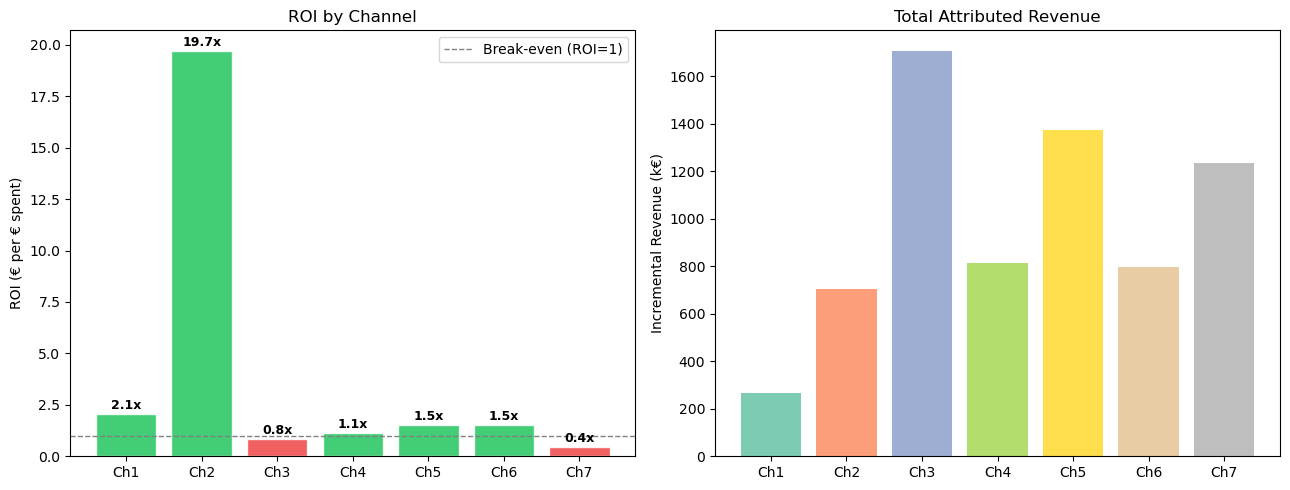

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = ['#22c55e' if r >= 1 else '#ef4444' for r in roi]
bars = ax1.bar(CHANNEL_LABELS, roi, color=bar_colors, alpha=0.85, edgecolor='white')
ax1.axhline(1, color='gray', ls='--', lw=1, label='Break-even (ROI=1)')
ax1.set_ylabel('ROI (€ per € spent)'); ax1.set_title('ROI by Channel')
for bar, v in zip(bars, roi):
    ax1.text(bar.get_x()+bar.get_width()/2, v+0.1, f'{v:.1f}x',
             ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.legend()

ax2.bar(CHANNEL_LABELS, contrib_rev/1e3, color=plt.cm.Set2(np.linspace(0,1,7)), alpha=0.85)
ax2.set_ylabel('Incremental Revenue (k€)'); ax2.set_title('Total Attributed Revenue')
plt.tight_layout(); plt.show()

## 11. Summary of Findings

| Question | Answer |
|---|---|
| How is carry-over modelled? | Geometric adstock: $a_t = x_t + \alpha \cdot a_{t-1}$, with $\alpha \sim \text{Beta}(2,3)$ per channel |
| Prior rationale | Beta(2,3) for decay (moderate carry-over); HalfNormal for beta (positive effects); weak informative priors elsewhere |
| Prior vs posterior | Priors produce wide revenue envelope; posteriors are substantially tighter and data-driven |
| Model performance | R²=0.42, MAPE≈20%. Acceptable for MMM without promotions/price data. R-hat≈1.00 (converged) |
| Best channel by ROI | **Channel 2** (≈20x ROI) — highest return, lowest spend; under-invested |
| Channels to cut | **Channels 3 & 7** — absorb majority of budget (~€5M total) with below-breakeven ROI |

In [16]:
print('='*60)
print('MODEL SUMMARY')
print('='*60)
print(f'Weeks of data:         {n}')
print(f'R² (posterior mean):   {r2:.3f}')
print(f'MAE:                   €{mae:,.0f}')
print(f'MAPE:                  {mape:.1f}%')
print()
print('Channel ROI ranking:')
for _, row in roi_df.iterrows():
    flag = ' ⭐ BEST' if row['ROI'] == roi_df['ROI'].max() else (
           ' ⚠️  BELOW BREAKEVEN' if row['ROI'] < 1.0 else '')
    print(f"  {row['Channel']}: ROI={row['ROI']:.2f}x  spend=€{row['Total Spend (€)']/1e3:.0f}k{flag}")

MODEL SUMMARY
Weeks of data:         104
R² (posterior mean):   0.420
MAE:                   €26,481
MAPE:                  19.8%

Channel ROI ranking:
  Ch2: ROI=19.72x  spend=€36k ⭐ BEST
  Ch1: ROI=2.06x  spend=€130k
  Ch5: ROI=1.54x  spend=€892k
  Ch6: ROI=1.52x  spend=€527k
  Ch4: ROI=1.13x  spend=€719k
  Ch3: ROI=0.84x  spend=€2029k ⚠️  BELOW BREAKEVEN
  Ch7: ROI=0.43x  spend=€2881k ⚠️  BELOW BREAKEVEN
